In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = r"E:\Pyhton code\Data Sets\archive\word embeddings\Files\glove.6B.50d.txt"

In [3]:
#Load vector
def read_glove_vecs(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        words = set()
        word_to_vec_map = {}

        for line in f:
            line = line.strip().split()
            curr_word = line[0]
            words.add(curr_word)
            word_to_vec_map[curr_word] = np.array(line[1:], dtype=np.float64)

    return words, word_to_vec_map


words, word_to_vec_map = read_glove_vecs(DATA_PATH)

print("Number of words:", len(words))
print("Vector size:", len(next(iter(word_to_vec_map.values()))))

Number of words: 400000
Vector size: 50


In [ ]:
# Cosine Similarity
def cosine_similarity(u, v):
    dot = np.dot(u, v)

    norm_u = np.linalg.norm(u)
    norm_v = np.linalg.norm(v)

    return dot / (norm_u * norm_v)

# Meaning: Measures how similar two word vectors are.
# - 1 → very similar direction
# - 0 → unrelated direction
# - -1 → opposite direction

In [11]:
#Practice
word1 = "king"
word2 = "queen"

u = word_to_vec_map[word1]
v = word_to_vec_map[word2]

similarity = cosine_similarity(u, v)

print(f"Similarity between '{word1}' and '{word2}': {similarity:.4f}")

Similarity between 'king' and 'queen': 0.7839


In [ ]:
#Analogy funtion
def complete_analogy(word_a, word_b, word_c, word_to_vec_map):

    word_a = word_a.lower()
    word_b = word_b.lower()
    word_c = word_c.lower()

    e_a = word_to_vec_map[word_a]
    e_b = word_to_vec_map[word_b]
    e_c = word_to_vec_map[word_c]

    target = e_b - e_a + e_c

    max_cosine_similarity = -100
    best_word = None

    for word in word_to_vec_map.keys():

        if word in {word_a, word_b, word_c}:
            continue

        similarity = cosine_similarity(target, word_to_vec_map[word])

        if similarity > max_cosine_similarity:
            max_cosine_similarity = similarity
            best_word = word

    return best_word, max_cosine_similarity

In [13]:
#Practice
tests = [
    ("man", "woman", "king"),
    ("man", "woman", "boy"),
    ("paris", "france", "italy"),
]

for a, b, c in tests:
    try:
        answer, score = complete_analogy(a, b, c, word_to_vec_map)
        print(f"{a} : {b} :: {c} : {answer}  (score={score:.4f})")
    except KeyError as e:
        print(f"Skipping {a}:{b}::{c} because {e} is not in the vocabulary.")

man : woman :: king : queen  (score=0.8610)
man : woman :: boy : girl  (score=0.9477)
paris : france :: italy : spain  (score=0.8109)


In [14]:
#Calculate gender direction
gender_direction = (
    word_to_vec_map["woman"] -
    word_to_vec_map["man"]
)

print("Gender direction shape:", gender_direction.shape)


Gender direction shape: (50,)


In [ ]:
#Inspect similarity to gender direction
gender_words = [
    "man",
    "woman",
    "boy",
    "girl",
    "king",
    "queen",
    "father",
    "mother",
    "engineer",
    "doctor",
    "nurse"
]

for word in gender_words:
    if word in word_to_vec_map:
        similarity = cosine_similarity(
            word_to_vec_map[word],
            gender_direction
        )

        print(f"{word:12s} {similarity:.4f}")

man          -0.1171
woman        0.3567
boy          0.1156
girl         0.3484
king         -0.1888
queen        0.2045
father       0.0342
mother       0.3402
engineer     -0.0804
doctor       0.1190
nurse        0.3803


In [16]:
#Neutralize - remove components of word vector that lies along the bias direction
def neutralize(word, gender_axis, word_to_vec_map):
    
    e = word_to_vec_map[word]

    # Projection of e onto the gender axis
    bias_component = (
        np.dot(e, gender_axis) /
        np.dot(gender_axis, gender_axis)
    ) * gender_axis

    # Remove the bias component
    e_debiased = e - bias_component

    return e_debiased

In [17]:
#Practice
neutral_words = [
    "engineer",
    "doctor",
    "teacher",
    "computer",
    "scientist",
    "lawyer"
]

print("Before vs After neutralization\n")

for word in neutral_words:

    if word not in word_to_vec_map:
        continue

    before = cosine_similarity(
        word_to_vec_map[word],
        gender_direction
    )

    debiased_vector = neutralize(
        word,
        gender_direction,
        word_to_vec_map
    )

    after = cosine_similarity(
        debiased_vector,
        gender_direction
    )

    print(
        f"{word:12s} "
        f"before={before: .6f} "
        f"after={after: .6f}"
    )

Before vs After neutralization

engineer     before=-0.080393 after= 0.000000
doctor       before= 0.118953 after=-0.000000
teacher      before= 0.179209 after= 0.000000
computer     before=-0.103304 after=-0.000000
scientist    before=-0.051930 after= 0.000000
lawyer       before= 0.019827 after= 0.000000


In [ ]:
#Equalization function
def equalize(pair, gender_axis, word_to_vec_map):

    w1, w2 = pair

    e_w1 = word_to_vec_map[w1]
    e_w2 = word_to_vec_map[w2]

    # Normalize gender axis
    gender_axis_unit = (
        gender_axis / np.linalg.norm(gender_axis)
    )

    # Average vector
    mu = (e_w1 + e_w2) / 2

    # Projection of average onto gender axis
    mu_B = (
        np.dot(mu, gender_axis_unit)
        * gender_axis_unit
    )

    # Component perpendicular to gender axis
    mu_orth = mu - mu_B

    # Projection of each word onto gender axis
    e_w1_B = (
        np.dot(e_w1, gender_axis_unit)
        * gender_axis_unit
    )

    e_w2_B = (
        np.dot(e_w2, gender_axis_unit)
        * gender_axis_unit
    )

    # Calculate equalized magnitudes
    corrected_e_w1_B = (
        np.sqrt(
            max(
                0,
                1 - np.linalg.norm(mu_orth) ** 2
            )
        )
        * (
            e_w1_B - mu_B
        )
        / np.linalg.norm(e_w1_B - mu_B)
    )

    corrected_e_w2_B = (
        np.sqrt(
            max(
                0,
                1 - np.linalg.norm(mu_orth) ** 2
            )
        )
        * (
            e_w2_B - mu_B
        )
        / np.linalg.norm(e_w2_B - mu_B)
    )

    # Combine orthogonal component + corrected gender component
    e1 = mu_orth + corrected_e_w1_B
    e2 = mu_orth + corrected_e_w2_B

    return e1, e2


    # Equalize a pair of gender-specific words.

    # Example:
    #     ("man", "woman")
    #     ("boy", "girl")

In [19]:
#Test Equalization
gender_pairs = [
    ("man", "woman"),
    ("boy", "girl"),
    ("father", "mother"),
    ("king", "queen")
]

for w1, w2 in gender_pairs:

    if w1 not in word_to_vec_map or w2 not in word_to_vec_map:
        print(f"Skipping ({w1}, {w2})")
        continue

    e1, e2 = equalize(
        (w1, w2),
        gender_direction,
        word_to_vec_map
    )

    sim1 = cosine_similarity(e1, gender_direction)
    sim2 = cosine_similarity(e2, gender_direction)

    print(f"\n{w1} / {w2}")
    print(f"{w1} gender similarity: {sim1:.4f}")
    print(f"{w2} gender similarity: {sim2:.4f}")


man / woman
man gender similarity: 0.0000
woman gender similarity: 0.0000

boy / girl
boy gender similarity: 0.0000
girl gender similarity: 0.0000

father / mother
father gender similarity: -0.0000
mother gender similarity: -0.0000

king / queen
king gender similarity: -0.0000
queen gender similarity: -0.0000


In [ ]:
#Visualize Word Vectors
def compute_pca(X, n_components=2):

    # Center the data
    X_centered = X - np.mean(X, axis=0)

    # Covariance matrix
    covariance_matrix = np.cov(
        X_centered,
        rowvar=False
    )

    # Eigenvalue decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(
        covariance_matrix
    )

    # Sort eigenvectors by decreasing eigenvalue
    sorted_indices = np.argsort(eigenvalues)[::-1]

    eigenvectors = eigenvectors[:, sorted_indices]

    # Select required components
    components = eigenvectors[:, :n_components]

    # Project data
    X_reduced = np.dot(
        X_centered,
        components
    )

    return X_reduced

In [21]:
visual_words = [
    "man",
    "woman",
    "boy",
    "girl",
    "king",
    "queen",
    "father",
    "mother",
    "doctor",
    "nurse",
    "engineer",
    "teacher",
    "computer",
    "scientist",
    "lawyer"
]

visual_words = [
    word for word in visual_words
    if word in word_to_vec_map
]

vectors = np.array([
    word_to_vec_map[word]
    for word in visual_words
])

vectors_2d = compute_pca(vectors)

print("Number of words:", len(visual_words))
print("2D shape:", vectors_2d.shape)

Number of words: 15
2D shape: (15, 2)


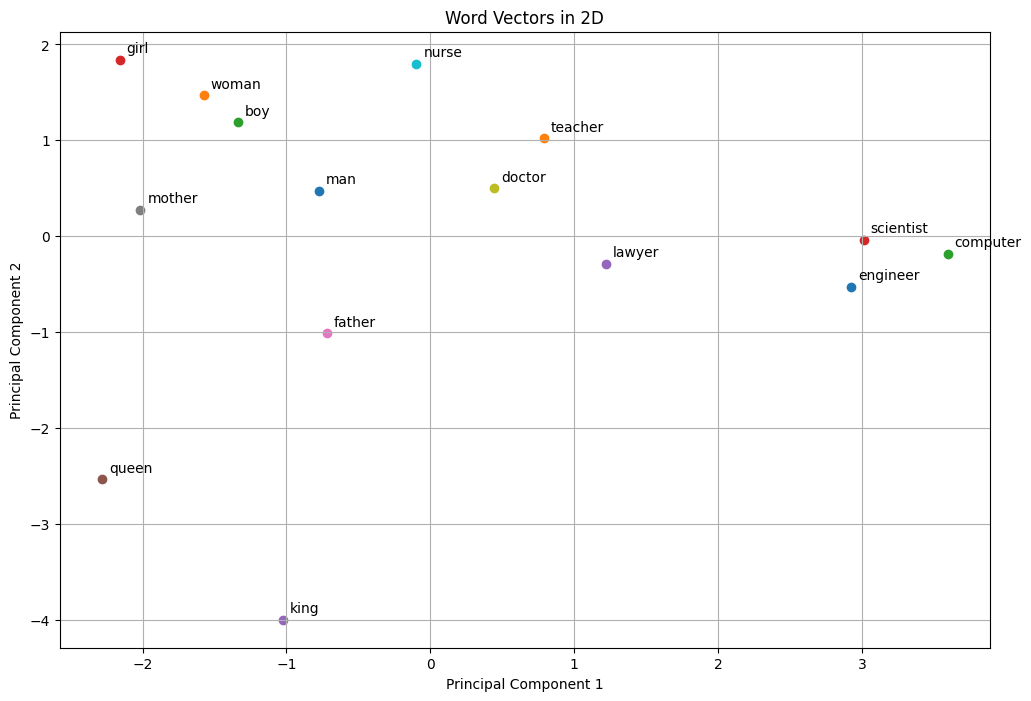

In [22]:
plt.figure(figsize=(12, 8))

for i, word in enumerate(visual_words):
    x = vectors_2d[i, 0]
    y = vectors_2d[i, 1]

    plt.scatter(x, y)
    plt.annotate(
        word,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Word Vectors in 2D")
plt.grid(True)
plt.show()

In [23]:
#Visualize Before vs After neutralization
neutral_words = [
    "engineer",
    "doctor",
    "teacher",
    "scientist",
    "lawyer",
    "computer"
]

available_neutral_words = [
    word for word in neutral_words
    if word in word_to_vec_map
]

original_vectors = np.array([
    word_to_vec_map[word]
    for word in available_neutral_words
])

debiased_vectors = np.array([
    neutralize(
        word,
        gender_direction,
        word_to_vec_map
    )
    for word in available_neutral_words
])

combined_vectors = np.vstack([
    original_vectors,
    debiased_vectors
])

combined_2d = compute_pca(
    combined_vectors,
    n_components=2
)

n = len(available_neutral_words)

original_2d = combined_2d[:n]
debiased_2d = combined_2d[n:]

print("Original vectors:", original_2d.shape)
print("Debiased vectors:", debiased_2d.shape)

Original vectors: (6, 2)
Debiased vectors: (6, 2)


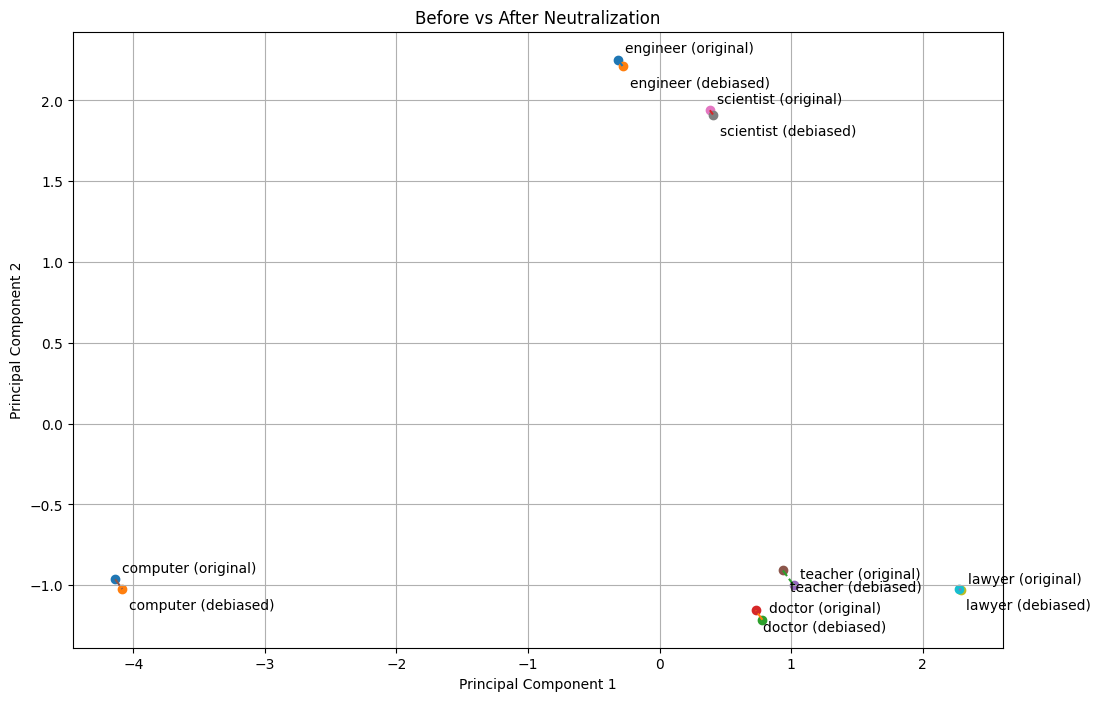

In [24]:
plt.figure(figsize=(12, 8))

for i, word in enumerate(available_neutral_words):

    x1, y1 = original_2d[i]
    x2, y2 = debiased_2d[i]

    plt.scatter(x1, y1)
    plt.annotate(
        word + " (original)",
        (x1, y1),
        xytext=(5, 5),
        textcoords="offset points"
    )

    plt.scatter(x2, y2)
    plt.annotate(
        word + " (debiased)",
        (x2, y2),
        xytext=(5, -15),
        textcoords="offset points"
    )

    plt.plot(
        [x1, x2],
        [y1, y2],
        linestyle="--"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Before vs After Neutralization")
plt.grid(True)
plt.show()

In [27]:
a = "donkey"
b = "woman"
c = "king"

answer, score = complete_analogy(
    a,
    b,
    c,
    word_to_vec_map
)

print(
    f"{a} : {b} :: {c} : {answer}"
)
print(f"Similarity score: {score:.4f}")

donkey : woman :: king : father
Similarity score: 0.8284


In [30]:
word1 = "girl"
word2 = "boy"

similarity = cosine_similarity(
    word_to_vec_map[word1],
    word_to_vec_map[word2]
)

print(
    f"Cosine similarity = {similarity:.4f}"
)

Cosine similarity = 0.9327


In [29]:
#Inspect vector arithmetic directly
word_a = "man"
word_b = "woman"
word_c = "king"

result_vector = (
    word_to_vec_map[word_b]
    - word_to_vec_map[word_a]
    + word_to_vec_map[word_c]
)

print("Result vector shape:", result_vector.shape)
print("First 10 values:")
print(result_vector[:10])

Result vector shape: (50,)
First 10 values:
[ 0.417366  0.90427  -1.00503  -0.062021  0.49726   0.80667  -0.14855
  0.80365  -0.15654  -0.66974 ]


In [31]:
gender_axis = (
    word_to_vec_map["woman"]
    - word_to_vec_map["man"]
)

engineer_before = cosine_similarity(
    word_to_vec_map["engineer"],
    gender_axis
)

engineer_after_vector = neutralize(
    "engineer",
    gender_axis,
    word_to_vec_map
)

engineer_after = cosine_similarity(
    engineer_after_vector,
    gender_axis
)

print("Engineer before:", engineer_before)
print("Engineer after :", engineer_after)

Engineer before: -0.0803928049452407
Engineer after : 1.7334663933503355e-17
